In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('../dataset/loan_data.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

Shape: (614, 13)

First 5 rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural   

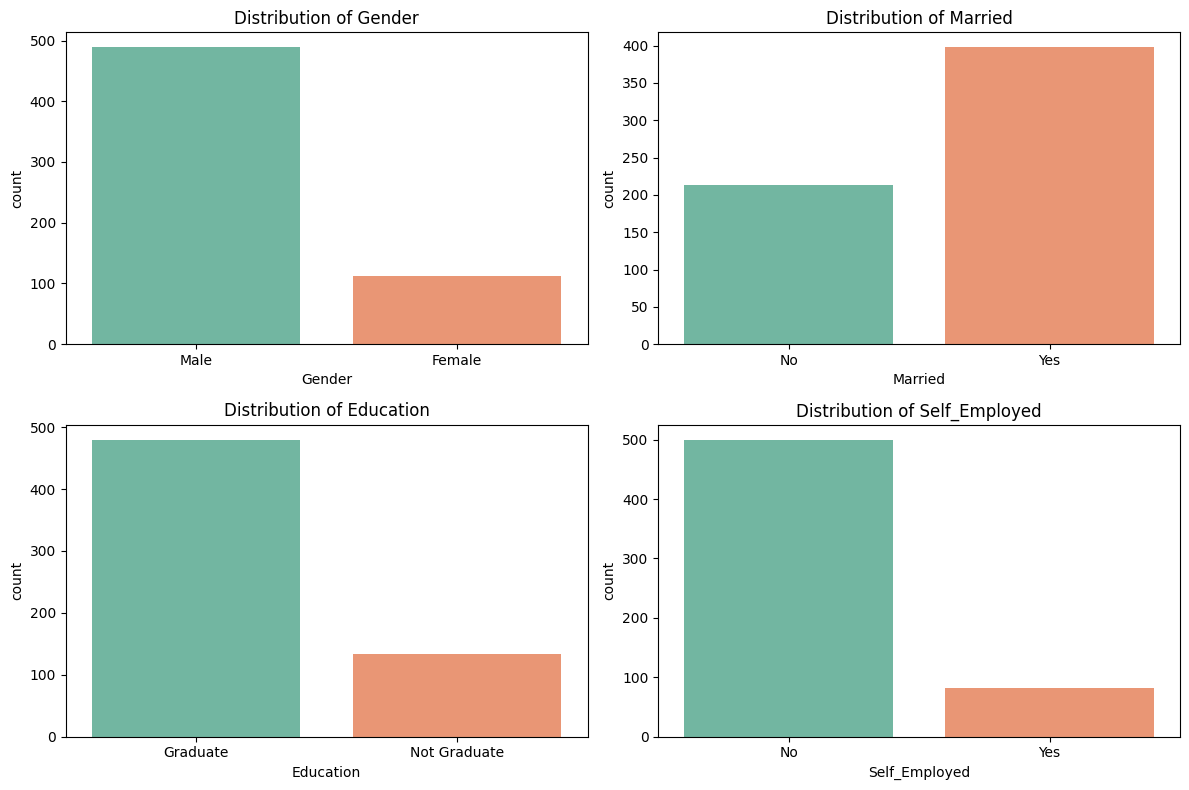

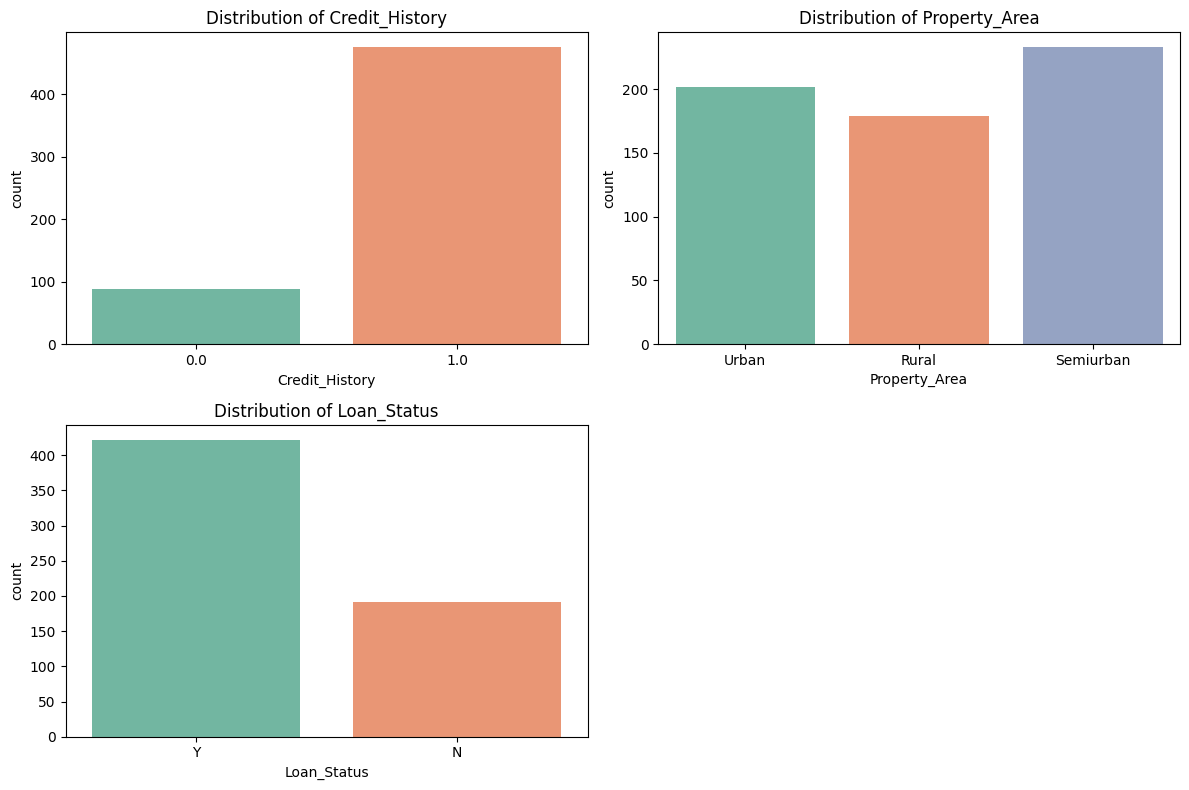

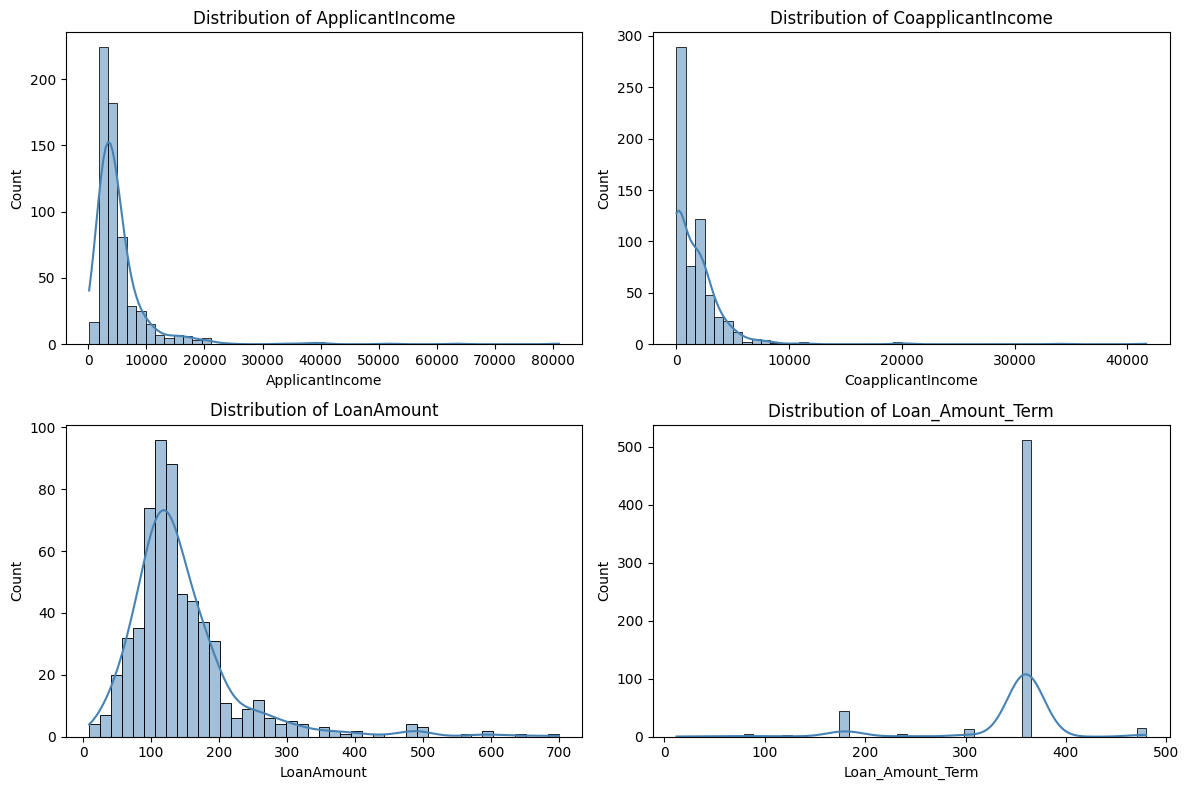

In [2]:
#Categorical
cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed',
            'Credit_History', 'Property_Area', 'Loan_Status']

for i in range(0, len(cat_cols), 4):
    batch = cat_cols[i:i+4]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    for j, col in enumerate(batch):
        sns.countplot(x=col, data=df, ax=axes[j], palette='Set2')
        axes[j].set_title(f'Distribution of {col}')
    for k in range(j+1, 4):
        axes[k].set_visible(False)
    plt.tight_layout()
    plt.show()

#Numerical
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

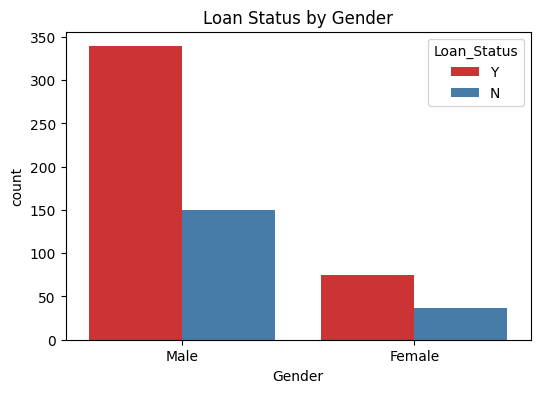

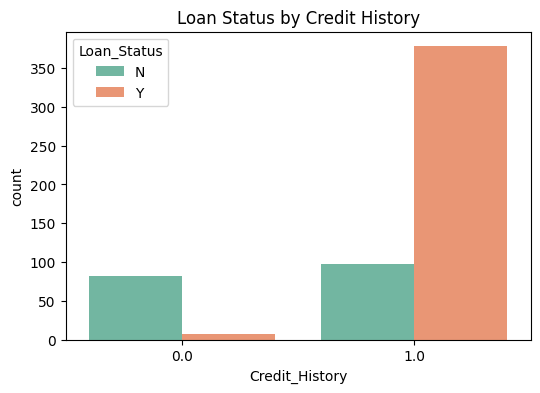

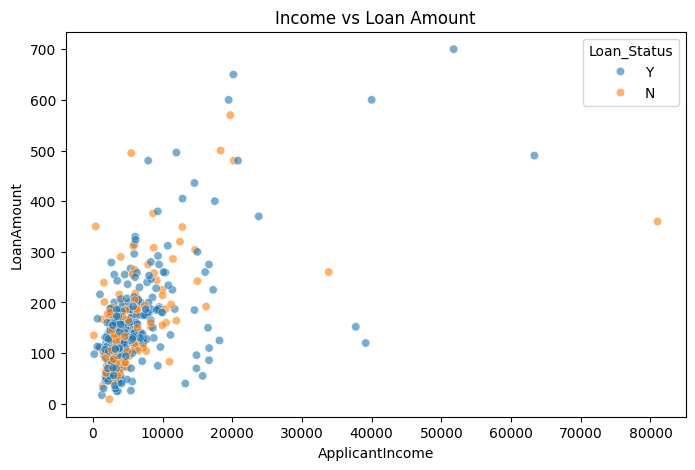

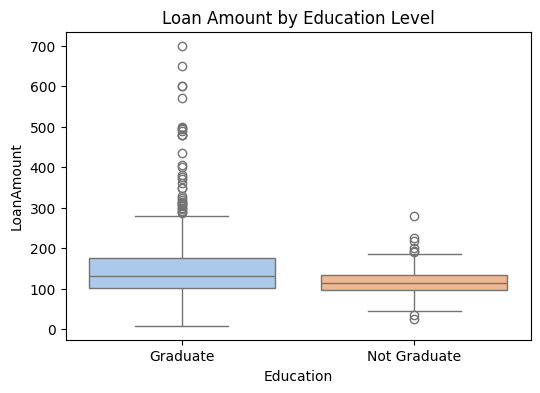

In [3]:
# Loan Status vs Gender
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', hue='Loan_Status', data=df, palette='Set1')
plt.title('Loan Status by Gender')
plt.savefig('../static/bivariate_gender.png')
plt.show()

# Loan Status vs Credit History
plt.figure(figsize=(6, 4))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df, palette='Set2')
plt.title('Loan Status by Credit History')
plt.savefig('../static/bivariate_credit.png')
plt.show()

# Applicant Income vs Loan Amount (scatter)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', hue='Loan_Status', data=df, alpha=0.6)
plt.title('Income vs Loan Amount')
plt.savefig('../static/bivariate_income_loan.png')
plt.show()

# Boxplot: Loan Amount by Education
plt.figure(figsize=(6, 4))
sns.boxplot(x='Education', y='LoanAmount', data=df, palette='pastel')
plt.title('Loan Amount by Education Level')
plt.savefig('../static/bivariate_edu_loan.png')
plt.show()

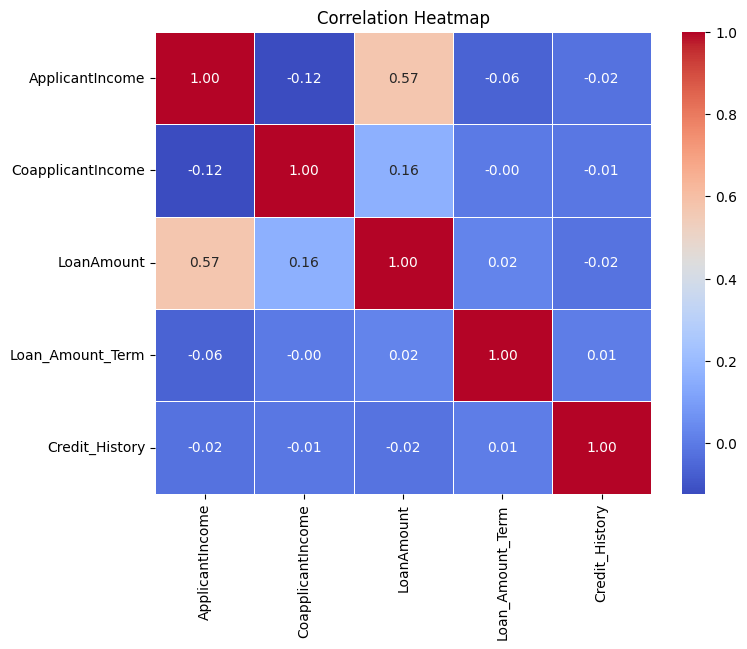

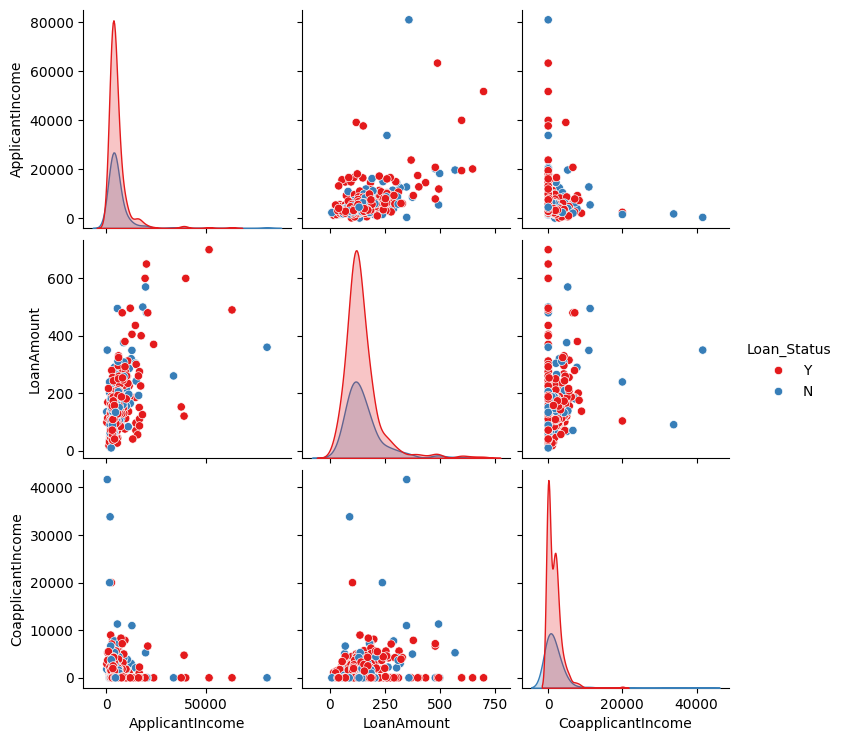

In [4]:
# Correlation heatmap (numerical features)
plt.figure(figsize=(8, 6))
numeric_df = df[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
                 'Loan_Amount_Term', 'Credit_History']].dropna()
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.savefig('../static/multivariate_heatmap.png')
plt.show()

# Pairplot
sns.pairplot(df[['ApplicantIncome', 'LoanAmount', 'CoapplicantIncome', 'Loan_Status']],
             hue='Loan_Status', palette='Set1', diag_kind='kde')
plt.savefig('../static/multivariate_pairplot.png')
plt.show()